<a href="https://colab.research.google.com/github/Vedia-JerezDaniel/Arize-tutorials/blob/main/Open_Source_LLMs_Getting_Started.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Open Source LLMs: Getting Started

### Goal: Start generating text in the next 120 seconds


## Getting Started

In this colab notebook, we'll want to use a **T4** GPU (A100/V100 will also work).  You may switch to this by going to "Runtime" then "Change Runtime Type"

This accelerated GPU will ensure inference of LLMs will not take forever.

In [1]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-6fe1fdea-b858-73c3-c0ff-6b0b44719fae)


To get around annoying text-wrapping issues, run this cell.

In [2]:
from IPython.display import HTML, display

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)

## Installing Dependencies

You'll need to install the following requirements

Python Libraries
- HuggingFace
- Llama-cpp-python

In [ ]:
# ## INSTALLING HUGGINGFACE
# !pip install huggingface-hub==0.17.1 -q

# ## INSTALLING llama-cpp-python
# # GPU llama-cpp-python; Starting from version llama-cpp-python==0.1.79, it supports GGUF
# !CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python --force-reinstall --upgrade --no-cache-dir
# !pip install numpy==1.24.4 -q
# !pip install llama-cpp-python --force-reinstall --upgrade --no-cache-dir
# !pip install gradio transformers torch pandas matplotlib seaborn

Next, you'll need to download the model weights from HuggingFace.

Here's a list of models you can choose from: https://huggingface.co/models?pipeline_tag=text-generation&sort=trending&search=GGUF

Note: The model you select **must** be of type "GGUF"

GGUF is...
- binary file format for storing models for inference
- designed for fast loading and saving of models
- easy to use (with a few lines of code)
- mmap (memory mapping) compatibility: models can be loaded using mmap for fast loading and saving.

In [3]:
# @title Select Large Language Model
selected_llm = 'Mistral-7B-OpenOrca' # @param ["Mistral-7B", "Mistral-7B-OpenOrca", "Llama-2-13B-Chat"]

model_dic = {"Mistral-7B":{"HF_REPO_NAME":"TheBloke/Mistral-7B-Instruct-v0.1-GGUF","HF_MODEL_NAME":"mistral-7b-instruct-v0.1.Q4_K_M.gguf"},
           "Mistral-7B-OpenOrca":{"HF_REPO_NAME":"TheBloke/Mistral-7B-OpenOrca-GGUF","HF_MODEL_NAME":"mistral-7b-openorca.Q5_K_M.gguf"},
             "Llama-2-13B-Chat":{"HF_REPO_NAME":"TheBloke/Llama-2-13B-chat-GGUF","HF_MODEL_NAME":"llama-2-13b-chat.Q4_K_S.gguf"}
             }

In [ ]:
!pip install chdb

In [4]:
import chdb

In [48]:
import os
import pandas as pd
import gradio as gr
# from transformers import pipeline

# Downgrade numpy to a version compatible with scipy


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import hf_hub_download

print(model_dic['Mistral-7B-OpenOrca'])
HF_REPO_NAME = model_dic['Mistral-7B-OpenOrca']['HF_REPO_NAME']
HF_MODEL_NAME = model_dic['Mistral-7B-OpenOrca']['HF_MODEL_NAME']
LOCAL_DIR_NAME = "models"

os.makedirs(LOCAL_DIR_NAME, exist_ok=True)
model_path = hf_hub_download(
    repo_id=HF_REPO_NAME, filename=HF_MODEL_NAME, local_dir=LOCAL_DIR_NAME
)

{'HF_REPO_NAME': 'TheBloke/Mistral-7B-OpenOrca-GGUF', 'HF_MODEL_NAME': 'mistral-7b-openorca.Q5_K_M.gguf'}


In [6]:
# !pip install llama-cpp-python --force-reinstall --upgrade --no-cache-dir

from llama_cpp import Llama

llm = Llama(
    model_path=model_path,
    n_threads=2, # Adjust based on your CPU cores for optimal performance
    n_batch=512, # Should be between 1 and n_ctx, consider the amount of VRAM in your GPU.
    n_gpu_layers=30, # The max for this model is 30 in a T4. For larger models (e.g., Llama 2 70B), you'll need fewer layers on the GPU.
    n_ctx=4096, # Context window
    verbose=False # Set to False to suppress verbose output during inference
)

llama_context: n_ctx_per_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


# The Fun Part

You're all ready to actually use this LLM!  Feel free to change the prompt variable to whatever you'd like.  Once you run the cell, it'll begin to stream the generated text.  The speed will depend on the GPU you selected (T4 vs. V100).

In [8]:
df_info = pd.read_csv("sample_data/info_table.csv")
df_cr = pd.read_csv("sample_data/cr_table.csv")
df_book = pd.read_csv("sample_data/book_table.csv")

print(df_info.shape, df_cr.shape, df_book.shape, "\n")
print(f"Selected hotels for demo: {df_book.HOTEL.unique()} ")

(356128, 3) (196861, 26) (196861, 15) 

Selected hotels for demo: [ 796968  344707   92123 ... 1029619   67708   17353] 


In [9]:
df_info.columns = df_info.columns.str.lower()
df_cr.columns = df_cr.columns.str.lower()
df_book.columns = df_book.columns.str.lower()

In [24]:
list_h = (df_cr.sort_values(by='total',ascending=False)['hotel'].unique()[:5]).tolist()
list_h

df_cr_f = df_cr[df_cr['hotel'].isin(list_h)]
df_book_f = df_book[df_book['hotel'].isin(list_h)]

In [31]:
df_cr_f

,timestamp,date,hotel,lt,los,occ,channel,ratecode,sourcemarket,dest,...,hna,ext,r,dup,other,err_client,diff_inc,diff_dec,diff_inc_apt,diff_dec_apt
190,2026-02-01 00:30:00.000,2026-02-01,7357,97,2,2A-0C,XML 3,B2C,IT,ROE,...,0,0,0,0,0,0,0,0,0,0
197,2026-02-01 00:30:00.000,2026-02-01,7357,97,2,2A-0C,XML 3,B2C,IT,ROE,...,0,0,0,0,0,0,0,0,0,1
199,2026-02-01 00:30:00.000,2026-02-01,7357,97,2,2A-0C,XML 3,B2C,IT,ROE,...,0,0,0,0,0,0,0,0,0,0
206,2026-02-01 00:30:00.000,2026-02-01,7357,97,2,2A-0C,XML 3,B2C,IT,ROE,...,0,0,0,0,0,0,0,0,0,1
223,2026-02-01 00:30:00.000,2026-02-01,7357,97,2,2A-0C,XML 3,FIT,IT,ROE,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196220,2026-02-09 23:00:00.000,2026-02-09,9113,62,4,2A-0C,XML 3,FIT,US,ATH,...,0,0,0,0,0,0,0,0,1,0
196221,2026-02-09 23:00:00.000,2026-02-09,741941,12,7,2A-0C,XML 3,FIT,DE,DXB,...,0,0,0,0,0,0,0,0,87,0
196270,2026-02-09 23:00:00.000,2026-02-09,7357,39,3,2A-0C,XML 3,B2C,CN,ROE,...,0,0,0,0,0,0,0,0,0,0
196274,2026-02-09 23:00:00.000,2026-02-09,741941,12,7,2A-0C,XML 3,FIT,DE,DXB,...,0,0,0,0,0,0,0,0,31,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [45]:
# @title Defining Tables Functions
def get_data(df_cr: pd.DataFrame, df_book: pd.DataFrame):
  elem_list = list(df_cr.columns)
  unwanted_elem = ['total','success','failed','no_diff','hna','ext','r','dup','other','err_client','diff_inc','diff_dec','diff_inc_apt','diff_dec_apt']
  elem_result = [ele for ele in elem_list if ele not in unwanted_elem]
  df_final = pd.merge(df_cr, df_book, how='left', on=elem_result, left_index=False, right_index=False).fillna(False)

  if 'hotel' in df_final.columns:
      df_final['hotel'] = df_final['hotel'].astype(int)

  sel_col = ['seq_hotel','hotel_code','des_hotel','spai_cod_pais']
  h_a = {'hotel':'Hotelbeds Hotel Code'}
  h_b = {'seq_hotel':'Hotelbeds Hotel Code'}

  df_result = pd.merge(df_final.rename(columns = h_a), df_info, how='left', on='client', left_index=False, right_index=False)

  df_result['Hotelbeds Hotel Code'] = df_result['Hotelbeds Hotel Code'].astype("string")

  print("✓ Created: Results table")

  return df_result

def get_accuracy():
  df_result = get_data(df_cr_f, df_book_f)

  df_result['err_ratio'] = round(((df_result['failed'] - df_result['err_client'] - df_result['dup']) / (df_result['total'] - df_result['err_client'] - df_result['dup']))*100,2)
  df_result['pdiff_ratio'] = round(((df_result['diff_inc'] + df_result['diff_dec']) / df_result['total'])*100,2)
  df_result['accuracy'] = 100 - df_result['err_ratio'] - df_result['pdiff_ratio']

  # if total_book.value:
  # Calculate error ratio
  df_result['err_ratio_b'] = round((df_result['b_failed'] / df_result['b_total'])*100,2)
  df_result['err_ratio_b'] = df_result['err_ratio_b'].fillna(0)
  # Calculate percentage book error

  # Calculate percentage book error supp
  total_book_error = df_result['b_failed'].sum()
  df_result['%_b_error_supp'] = ((df_result['b_failed']/total_book_error).mul(100)).round(2)
  # Calculate percentage contribution to book error supp
  i_be = ((total_book_error / df_result['b_total'].sum()) * 100).round(2)
  df_result['%_contr_b_error_supp'] = (df_result['failed']/total_book_error).mul(i_be).round(2)
  # Calculate the Accuracy Impact
  b_r = 1-(df_result['err_ratio_b']/100)
  acc = (df_result['b_success'].sum()/df_result['b_total'].sum())
  df_result['acc_imp'] = (b_r-acc)*df_result['b_failed']

  # df_result.drop(['#_book_error'],axis=1, inplace=True)

  # if total_lc.value:
  # Calculate the error ratio for 'Valuation'
  df_result['err_ratio_v'] = round((df_result['failed']/df_result['total']) * 100,2).fillna(0)

  # Calculate percentage Valuation error supp
  total_v_error = df_result['failed'].sum()
  df_result['%_v_error_supp'] = ((df_result['failed']/total_v_error).mul(100)).round(2)
  # Calculate percentage contribution to Valuation error supp
  i_ve = ((total_v_error/df_result['total'].sum())*100).round(2)
  df_result['%_contr_v_error_supp']=(df_result['failed']/total_v_error).mul(i_ve).round(2)
  # Valuation: Calculate the Accuracy Impact
  v_r = (1-df_result['err_ratio_v']/100)
  acc_v = (df_result['success'].sum()/df_result['total'].sum())
  df_result['acc_imp_v'] = (v_r-acc_v)*df_result['failed']

  df_result.drop(['err_ratio_v'],axis=1, inplace=True)

  print("✓ Created: Accuracy results")

  return df_result

def clean_data():

  df_result = get_accuracy()

  df_result = df_result.rename(columns={'hotel':'Hotelbeds Hotel Code',
  'hotel_code':'External Hotel Code','spai_cod_pais':'Hotel Country','des_hotel':'Hotel Name',
  'ratecode':'Rate Code','sourcemarket':'Source Market','err_ratio':'Error Ratio (%)',
  'pdiff_ratio':'Price Diff Ratio (%)','accuracy':'Accuracy (%)',
  'b_total':'Total Bookings','total':'Total Live Checks',
  'los': 'Lenght Of Stay','lt': 'Lead Time','dest': 'Destination','occ': 'Occupancy',
  'ratekeyage': 'Rate Key Age','client':'API Key','date':'Date','timestamp':'Timestamp'})

  if 'acc_imp' in df_result.columns:
      df_result.rename(columns={'err_ratio_b':'Booking error ratio (%)'}, inplace=True)
      # df_result.rename(columns={'#_book_error':'Number Bookings errors'}, inplace=True)
      df_result.rename(columns={'%_b_error_supp':'Booking error Supplier (%)'}, inplace=True)
      df_result.rename(columns={'%_contr_b_error_supp':'Contribution Total Booking error ratio (%)'}, inplace=True)
      df_result.rename(columns={'acc_imp':'Booking Accuracy Impact'}, inplace=True)

  if 'acc_imp_v' in df_result.columns:
  # df_result.rename(columns={'#_book_error':'Number Bookings errors'}, inplace=True)
      df_result.rename(columns={'%_v_error_supp':'Valuations error Supplier (%)'}, inplace=True)
      df_result.rename(columns={'%_contr_v_error_supp':'Contribution Total Valuations error ratio (%)'}, inplace=True)
      df_result.rename(columns={'acc_imp_v':'Valuations Accuracy Impact'}, inplace=True)

  if 'brand' in df_result.columns:
      df_result.rename(columns={'brand':'Brand'}, inplace=True)

  if 'seq_ttoo' in df_result.columns:
      df_result.rename(columns={'nom_corto_ttoo':'TTOO_name', 'seq_ttoo':'TTOO_code'}, inplace=True)

  df_result.sort_values(by='Accuracy (%)',inplace=True)

  dc = ['Total Live Checks','success','failed','no_diff','hna','ext','r','dup','other','err_client',
       'diff_inc','diff_dec','diff_inc_apt','diff_dec_apt','Total Bookings','b_success','b_failed']

  dc.remove('Total Bookings')
  df_result.drop(dc ,axis=1, inplace=True)
  df_result.sort_values(by='Total Bookings',ascending=False, inplace=True)

  dc.remove('Total Live Checks')
  # df_result.drop(dc ,axis=1, inplace=True)
  df_result.sort_values(by='Total Bookings',ascending=False, inplace=True)

  print("✓ Created: Final table")

  return df_result

In [59]:
df_result.columns


Index(['Timestamp', 'Date', 'Hotelbeds Hotel Code', 'Lead Time',
       'Lenght Of Stay', 'Occupancy', 'channel', 'Rate Code', 'Source Market',
       'Destination', 'API Key', 'Rate Key Age', 'Total Bookings',
       'client_shortname', 'client_id', 'Error Ratio (%)',
       'Price Diff Ratio (%)', 'Accuracy (%)', 'Booking error ratio (%)',
       'Booking error Supplier (%)',
       'Contribution Total Booking error ratio (%)', 'Booking Accuracy Impact',
       'Valuations error Supplier (%)',
       'Contribution Total Valuations error ratio (%)',
       'Valuations Accuracy Impact'],
      dtype='object')

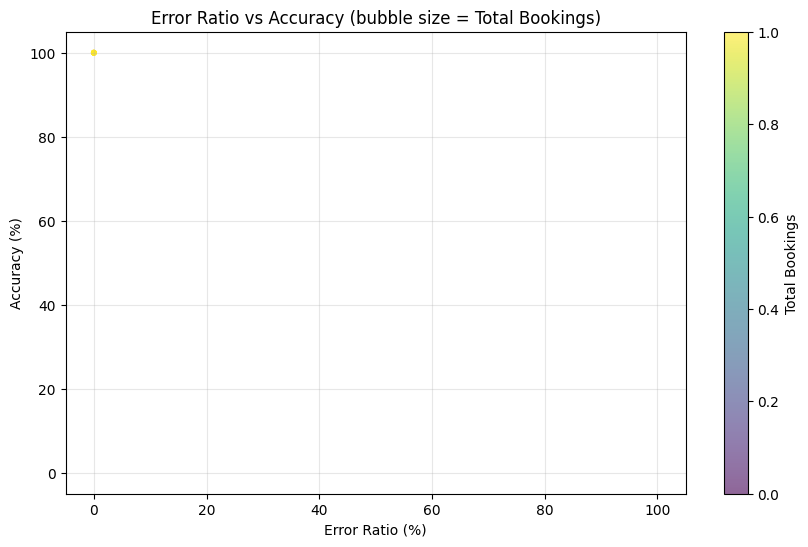

In [62]:
plt.figure(figsize=(10, 6))
plt.scatter(df_result['Error Ratio (%)'], df_result['Accuracy (%)'],
            s=df_result['Total Bookings']*10, alpha=0.6, c=df_result['Total Bookings'], cmap='viridis')
plt.xlabel('Error Ratio (%)')
plt.ylabel('Accuracy (%)')
plt.title('Error Ratio vs Accuracy (bubble size = Total Bookings)')
plt.colorbar(label='Total Bookings')
plt.grid(alpha=0.3)
plt.savefig('error_vs_accuracy.png', dpi=100, bbox_inches='tight')
plt.show()

In [56]:
# @title Define Plotting Functions
def plot_accuracy_by_hotel():
    plt.figure(figsize=(12, 6))
    top_hotels = df_result.nlargest(10, 'Accuracy (%)')
    sns.barplot(data=top_hotels, x='Accuracy (%)', y='Hotelbeds Hotel Code', palette='Greens_r')
    plt.title('Top 10 Hotels by Accuracy')
    plt.tight_layout()
    plt.savefig('accuracy_by_hotel.png', dpi=100, bbox_inches='tight')
    plt.show()
    return "✓ Created: Top 10 Hotels by Accuracy"

def plot_error_vs_accuracy():
    plt.figure(figsize=(10, 6))
    plt.scatter(df_result['Error Ratio (%)'], df_result['Accuracy (%)'],
                s=df_result['Total Bookings']*10, alpha=0.6, c=df_result['Total Bookings'], cmap='viridis')
    plt.xlabel('Error Ratio (%)')
    plt.ylabel('Accuracy (%)')
    plt.title('Error Ratio vs Accuracy (bubble size = Total Bookings)')
    plt.colorbar(label='Total Bookings')
    plt.grid(alpha=0.3)
    plt.savefig('error_vs_accuracy.png', dpi=100, bbox_inches='tight')
    plt.show()
    return "✓ Created: Error vs Accuracy Scatter Plot"

def plot_accuracy_by_country():
    country_accuracy = df.groupby('Hotel Country')['Accuracy (%)'].mean().sort_values(ascending=False)
    plt.figure(figsize=(12, 8))
    sns.barplot(x=country_accuracy.values, y=country_accuracy.index, palette='RdYlGn')
    plt.title('Average Accuracy by Hotel Country')
    plt.xlabel('Average Accuracy (%)')
    plt.tight_layout()
    plt.savefig('accuracy_by_country.png', dpi=100, bbox_inches='tight')
    plt.show()
    return "✓ Created: Accuracy by Country"

def plot_rate_code_performance():
    rate_performance = df.groupby('Rate Code').agg({
        'Accuracy (%)': 'mean',
        'Error Ratio (%)': 'mean',
        'Total Bookings': 'sum'
    }).sort_values('Accuracy (%)', ascending=False)

    rate_performance[['Accuracy (%)', 'Error Ratio (%)']].plot(kind='bar', figsize=(10, 6))
    plt.title('Accuracy vs Error Ratio by Rate Code')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    plt.legend(['Accuracy', 'Error Ratio'])
    plt.tight_layout()
    plt.savefig('rate_code_performance.png', dpi=100, bbox_inches='tight')
    plt.show()
    return "✓ Created: Rate Code Performance"

def plot_source_market_analysis():
    market_data = df.groupby('Source Market').agg({
        'Accuracy (%)': 'mean',
        'Total Bookings': 'sum'
    }).sort_values('Total Bookings', ascending=False).head(15)

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()

    x = range(len(market_data))
    ax1.bar(x, market_data['Total Bookings'], alpha=0.7, color='steelblue')
    ax2.plot(x, market_data['Accuracy (%)'], color='red', marker='o', linewidth=2)

    ax1.set_xlabel('Source Market')
    ax1.set_ylabel('Total Bookings', color='steelblue')
    ax2.set_ylabel('Accuracy (%)', color='red')
    ax1.set_xticks(x)
    ax1.set_xticklabels(market_data.index, rotation=45)
    plt.title('Bookings and Accuracy by Source Market')
    plt.tight_layout()
    plt.savefig('source_market_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
    return "✓ Created: Source Market Analysis"

In [49]:
df = clean_data()

✓ Created: Results table
✓ Created: Accuracy results
✓ Created: Final table


/tmp/ipython-input-1745868615.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_result['err_ratio_b'].fillna(0, inplace=True)


In [51]:
# Load your hotel data
# with open('hotel_data.json', 'r') as f:
#     data = json.load(f)
# df = pd.DataFrame(data)


# @title Define LLM Task Processing
def process_llm_task(user_request):
    # Create a prompt that includes the available functions
    prompt = f"""
      You are an AI assistant that helps with data analysis. You have access to the following functions:
      1. plot_accuracy_by_hotel() - Creates a bar chart of top 10 hotels by accuracy
      2. plot_error_vs_accuracy() - Creates a scatter plot of error ratio vs accuracy
      3. plot_accuracy_by_country() - Creates a bar chart of accuracy by country
      4. plot_rate_code_performance() - Creates a bar chart comparing rate codes
      5. plot_source_market_analysis() - Creates a dual-axis chart of bookings and accuracy by source market

User request: {user_request}

Based on the user's request, determine which function to call. Reply with only the function name.
"""

    # Get LLM response
    response = llm(prompt, max_tokens=50, stop=["\n"], echo=False)

    # Extract function name from response
    function_name = None
    for func_name in ["plot_accuracy_by_hotel", "plot_error_vs_accuracy", "plot_accuracy_by_country",
                      "plot_rate_code_performance", "plot_source_market_analysis"]:
        if func_name in response['choices'][0]['text'].lower():
            function_name = func_name
            break

    if function_name:
        print(f"🤖 LLM selected: {function_name}")
        result = globals()[function_name]()
        print(result)
        return result
    else:
        print("❌ Could not identify function from LLM response")
        return "I couldn't understand your request. Please ask for specific analysis like 'show accuracy by hotel' or 'compare error ratios'."

# @title Example Usage
# # Test the system with different user requests
# print("Testing with different user requests:")

# # Test 1: General analysis request
# print("\n1. User asks: 'Show me hotel accuracy analysis'")
# process_llm_task("Show me hotel accuracy analysis")

# # Test 2: Specific request
# print("\n2. User asks: 'Create a plot comparing error ratios and accuracy'")
# process_llm_task("Create a plot comparing error ratios and accuracy")

# # Test 3: Country analysis
# print("\n3. User asks: 'Analyze performance by country'")
# process_llm_task("Analyze performance by country")

# # Test 4: Rate code analysis
# print("\n4. User asks: 'Compare rate code performance'")
# process_llm_task("Compare rate code performance")

# # Test 5: Source market analysis
# print("\n5. User asks: 'Analyze source markets'")
# process_llm_task("Analyze source markets")

In [57]:
plot_accuracy_by_hotel()

ValueError: Could not interpret value `Hotel Name` for `y`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [54]:
print("Testing with different user requests:")

# Test 1: General analysis request
print("\n1. User asks: 'Show hotel accuracy analysis'")
process_llm_task("Show accuracy by hotel")

Testing with different user requests:

1. User asks: 'Show hotel accuracy analysis'
❌ Could not identify function from LLM response


"I couldn't understand your request. Please ask for specific analysis like 'show accuracy by hotel' or 'compare error ratios'."

In [ ]:
# Load your hotel data
# with open('hotel_data.json', 'r') as f:
#     data = json.load(f)
# df = pd.DataFrame(data)


# @title Define LLM Task Processing
def process_llm_task(user_request):
    # Create a prompt that includes the available functions
    prompt = f"""
You are an AI assistant that helps with data analysis. You have access to the following functions:
1. plot_accuracy_by_hotel() - Creates a bar chart of top 10 hotels by accuracy
2. plot_error_vs_accuracy() - Creates a scatter plot of error ratio vs accuracy
3. plot_accuracy_by_country() - Creates a bar chart of accuracy by country
4. plot_rate_code_performance() - Creates a bar chart comparing rate codes
5. plot_source_market_analysis() - Creates a dual-axis chart of bookings and accuracy by source market

User request: {user_request}

Based on the user's request, determine which function to call. Reply with only the function name.
"""

    # Get LLM response
    response = llm(prompt, max_tokens=50, stop=["\n"], echo=False)

    # Extract function name from response
    function_name = None
    for func_name in ["plot_accuracy_by_hotel", "plot_error_vs_accuracy", "plot_accuracy_by_country",
                      "plot_rate_code_performance", "plot_source_market_analysis"]:
        if func_name in response['choices']['text'].lower():
            function_name = func_name
            break

    if function_name:
        print(f"🤖 LLM selected: {function_name}")
        result = globals()[function_name]()
        print(result)
        return result
    else:
        print("❌ Could not identify function from LLM response")
        return "I couldn't understand your request. Please ask for specific analysis like 'show accuracy by hotel' or 'compare error ratios'."

# @title Example Usage
# Test the system with different user requests
print("Testing with different user requests:")

# Test 1: General analysis request
print("\n1. User asks: 'Show me hotel accuracy analysis'")
process_llm_task("Show me hotel accuracy analysis")

# Test 2: Specific request
print("\n2. User asks: 'Create a plot comparing error ratios and accuracy'")
process_llm_task("Create a plot comparing error ratios and accuracy")

# Test 3: Country analysis
print("\n3. User asks: 'Analyze performance by country'")
process_llm_task("Analyze performance by country")

# Test 4: Rate code analysis
print("\n4. User asks: 'Compare rate code performance'")
process_llm_task("Compare rate code performance")

# Test 5: Source market analysis
print("\n5. User asks: 'Analyze source markets'")
process_llm_task("Analyze source markets")

,Hotelbeds Hotel Code,Rate Code,Source Market,Total Bookings,External Hotel Code,Hotel Name,Hotel Country,Error Ratio (%),Price Diff Ratio (%),Accuracy (%),Booking error ratio (%),Booking error Supplier (%),Contribution Total Booking error ratio (%),Booking Accuracy Impact,Valuations error Supplier (%),Contribution Total Valuations error ratio (%),Valuations Accuracy Impact
50,69644,FIT,AU,1,CAJ170400,Pathumwan Princess Hotel,TH,0.00,0.0,100.00,0.0,NaN,NaN,0.0,0.00,0.00,0.000000
44,126313,B2C,AU,1,CAG686900,Horset Opera,FR,0.00,0.0,100.00,0.0,NaN,NaN,0.0,0.00,0.00,0.000000
66,69644,FIT,IL,1,CAJ170400,Pathumwan Princess Hotel,TH,0.00,0.0,100.00,0.0,NaN,NaN,0.0,0.00,0.00,0.000000
51,220043,FITNRF,SA,1,CAZ447700,Ramee Grand hotel & Spa,BH,0.00,0.0,100.00,0.0,NaN,NaN,0.0,0.00,0.00,0.000000
21,69644,FIT,PT,0,CAJ170400,Pathumwan Princess Hotel,TH,14.71,0.0,85.29,0.0,NaN,NaN,0.0,2.42,0.04,-0.659195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,69644,FIT,DE,0,CAJ170400,Pathumwan Princess Hotel,TH,0.00,0.0,100.00,0.0,NaN,NaN,0.0,0.00,0.00,0.000000
102,69644,B2C,UK,0,CAJ170400,Pathumwan Princess Hotel,TH,0.00,0.0,100.00,0.0,NaN,NaN,0.0,0.00,0.00,0.000000
103,485142,FITNRF,AE,0,CBC360500,Wyndham Garden Manama,BH,0.00,0.0,100.00,0.0,NaN,NaN,0.0,0.00,0.00,0.000000
104,69644,B2C,US,0,CAJ170400,Pathumwan Princess Hotel,TH,0.00,0.0,100.00,0.0,NaN,NaN,0.0,0.00,0.00,0.000000
